# Compartmental Modeling Project

Model something that changes or flows


## Overview

In this project you will design, build, and present a compartmental model of a system of your choosing. You may work alone or with one partner.

Your model can describe anything that involves populations or quantities moving between states — disease spread, rumor dynamics, predator-prey ecosystems, zombie outbreaks, coffee cooling, drug pharmacokinetics, opinion change, or anything else that genuinely interests you.


## Your task:

Create a single **folder** containing:

-  **Model diagram** Write on paper or PowerPoint/Figma/draw.io, Boxes (or images) and arrows showing your compartments
-  **Equations**  Written in this notebook or on paper - The ODE system governing your model
- **Code** ipynb file, make a new notebook
-  **Visualizations** | Matplotlib / Plotly figures | At least 1 meaningful plots |
-  **Summary** Markdown cell in this notebook - Reflection on what the model shows

## Possible topics

| Idea | Compartments (example) |
|---|---|
| Flu season at a university | Susceptible → Infected → Recovered → Susceptible (SIRS) |
| Coffee cooling in a room | Hot → Warm → Cold (with ambient temperature) |
| Drug in the body | Gut → Bloodstream → Tissue → Excreted |
| Rumor spreading on social media | Ignorant → Spreader → Stifler |
| Fish population with fishing pressure | Juvenile → Adult → Harvested |
| Battery charge/discharge cycle | Charged → Discharging → Depleted → Charging |
| Student stress during exam season | Relaxed → Stressed → Burned Out → Recovered |
| Zombie apocalypse | Human → Infected → Zombie → Removed |
| Vampire population dynamics | Human → Bitten → Vampire → Staked |
| Alien invasion | Unaware → Aware → Resisting → Assimilated |
| Magic potion spreading through a village | Normal → Enchanted → Immune |
| Robot uprising | Obedient → Questioning → Rogue → Decommissioned |

## Part 1 — The Model Diagram

Draw your compartmental model.

- Each **compartment** (state) is a labeled box or circle
- Each **arrow** between compartments has a label showing the rate or parameter driving it
- Any flows **in** (births, immigration) or **out** (death, removal) of the system are shown


### Insert Your Diagram

Once you have an image, upload it to the same folder as this one, in your new notebook, copy the following code and replace the link with your image link

In [1]:
from IPython.display import Image, display

# Replace with the path to your diagram image
display(Image(filename="model_example.jpeg", width=600))

FileNotFoundError: [Errno 2] No such file or directory: 'model_example.jpeg'

## Part 2 — The Equations

Translate your diagram into a system of **ordinary differential equations (ODEs)**.

Every arrow in your diagram becomes a term in an equation. Arrows **leaving** a compartment are negative; arrows **entering** are positive.

every step, for each group, what is the net change at every instant? or how many individuals are entering minus how many are leaving?

### Your Model

Write your equations on your model, upload another photo

## Part 3 — The Code

Implement your model numerically using `scipy.integrate.solve_ivp`.

The code below is a **template** built around the SIR example. Modify every section marked with `# TODO` to match your own model.

Copy the tructure to your new notebook and modify it

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [5]:
# PARAMETERS
# TODO: Replace these with your own parameters and values.

beta  = 0.3   # transmission rate (1/day)
gamma = 0.1   # recovery rate (1/day)
N     = 1000  # total population

# INITIAL CONDITIONS
# TODO: Replace with your compartments' starting values.

S0 = N - 10   # initial susceptible
I0 = 10       # initial infected
R0 = 0        # initial recovered

y0 = [S0, I0, R0]  # initial state vector

# TIME SPAN
# TODO: Choose a time range that shows interesting dynamics.

t_start = 0
t_end   = 160   # days
t_eval  = np.linspace(t_start, t_end, 100)

In [6]:
# ODE SYSTEM
# TODO: Rewrite this function to match YOUR equations from Part 2.
#       - The function must return a list of derivatives in the same order as y0.
#       - You can pass parameters via closure (as shown)

def model(t, y):
    S, I, R = y  # TODO: unpack your compartments

    # TODO: Write your equations here
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I

    return [dS, dI, dR]  # TODO: return in the same order as y0

In [7]:
# SOLVE
sol = solve_ivp(
    fun     = model,
    t_span  = (t_start, t_end),
    y0      = y0,
    t_eval  = t_eval,
    method  = "RK45",   # Runge-Kutta 4(5) — good default
    dense_output = True
)

# Check it worked
print("Solver status:", sol.message)

# Unpack solution
# TODO: rename variables to match your compartments
t = sol.t
S, I, R = sol.y

Solver status: The solver successfully reached the end of the integration interval.


## Part 4 — Visualizations

Create **at least one** meaningful plots. Think about what each plot is trying to *show* — a good visualization tells a story.

**Required:** Plot 1 — time series of all compartments  
**Optional:** Plot 2 — something that reveals deeper insight (see ideas below)  

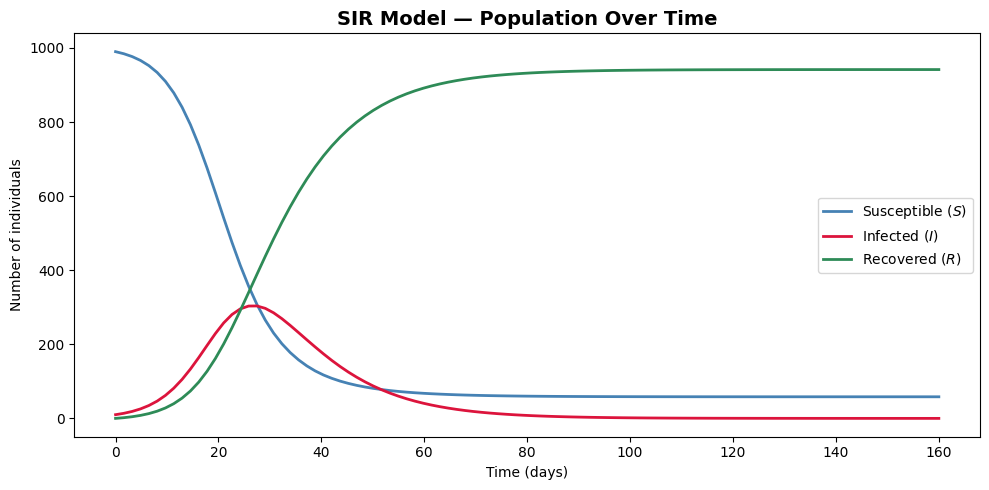

In [8]:
# PLOT 1: Time Series
# TODO: Rename labels and colors to match your compartments.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t, S, label="Susceptible ($S$)",  color="steelblue",  linewidth=2)
ax.plot(t, I, label="Infected ($I$)",     color="crimson",    linewidth=2)
ax.plot(t, R, label="Recovered ($R$)",    color="seagreen",   linewidth=2)

# TODO: Update title and axis labels
ax.set_title("SIR Model — Population Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Number of individuals")
ax.legend()

plt.tight_layout()
plt.savefig("plot_timeseries.png", dpi=150)  # saves for your repo
plt.show()

In [ ]:
# PLOT 2: Your Choice
# TODO: Replace this with your own second plot.


In [9]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

S, I, R = sol.y

# Create a Structured Grid for the Dots (coordinates for each dot)
# N = 100
grid_cols = N/10
grid_rows = 10
x_coords, y_coords = np.meshgrid(np.arange(grid_cols), np.arange(grid_rows))
x_coords = x_coords.flatten()
y_coords = y_coords.flatten()

# Define color palette
colors = {
    'S': '#1f77b4',
    'I': '#d62728',
    'R': '#2ca02c'
}

# Setup Plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(x_coords, y_coords, c=['#1f77b4']*N, s=60, edgecolors='none')
ax.set_title("SIR Model Grid Simulation", fontsize=14, pad=15)
ax.axis('off')

# creates a text box on the plot that you can update during the simulation
stats_text = ax.text(0.5, -0.05, "", transform=ax.transAxes, ha="center", fontsize=12,
                     bbox=dict(boxstyle="round", facecolor="white"))

# Animation Update Function
def update(frame):
    # 1. Get population counts for this frame
    s_count = int(np.round(S[frame]))
    i_count = int(np.round(I[frame]))
    r_count = N - s_count - i_count

    # 2. Assign categories to match the calculated proportions
    states = (['S'] * s_count) + (['I'] * i_count) + (['R'] * r_count)

    # Shuffle randomly so the outbreak looks scattered across the community
    np.random.seed(frame)
    np.random.shuffle(states)

    # Map back to hex color strings
    frame_colors = [colors[state] for state in states]
    scatter.set_color(frame_colors)

    # Update the status bar below the grid
    stats_text.set_text(
        f"Day: {sol.t[frame]:.1f}  |  "
        f"Susceptible: {s_count}  |  "
        f"Infected: {i_count}  |  "
        f"Recovered: {r_count}"
    )

    return scatter, stats_text

# Run the animation
ani = FuncAnimation(fig, update, frames=len(t_eval), interval=50, blit=True)

plt.close()
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

## Part 5 — Summary

Please briefly describe your model and explain your findings.

Think about
- What We Modeled
- What the Model Shows
- What parameters were used
- Assumptions & Limitations
- Findings